## Useful functions

In [104]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize
from scipy.linalg import norm
from scipy.linalg import expm, sinm, cosm
import random
import cvxpy as cp
import itertools
import random
from scipy.linalg import eigh


sx = np.array([[0, 1], [1, 0]])  
sz = np.array([[1, 0], [0, -1]])  
sy = np.array([[0, -1j], [1j, 0]])  
identity = np.eye(2)  
I = np.eye(2)
s_plus = np.array([[0, 1], [0, 0]])
s_minus = np.array([[0, 0], [1, 0]])

def kron_n(*matrices):
    result = np.array([[1.0]])  
    for matrix in matrices:
        result = np.kron(result, matrix)
    return result

In [105]:
def xxz_hamiltonian(L, J, Delta):
    H = np.zeros((2**L, 2**L), dtype=complex)  
    # print H shape
    print(H.shape)
    for j in range(L - 1):
        
        op_list_x = [identity] * (L)
        # print op_list_x shape
        # print(op_list_x)

        op_list_x[j] = sx
        op_list_x[j+1] = sx

        H += J * kron_n(*op_list_x)

    for j in range(L - 1):
        op_list_y = [identity] * (L)
        op_list_y[j] = sy
        op_list_y[j+1] = sy
        H += J * kron_n(*op_list_y)

    for j in range(L - 1):
        op_list_z = [identity] * (L)
        op_list_z[j] = sz
        op_list_z[j+1] = sz
        H += Delta * kron_n(*op_list_z)

    return H

In [106]:
def pauli_operator(pauli_string):
    # print pauli_string
    op_list = [identity] * len(pauli_string)  # initialize the operator list with identity matrices

    for i, char in enumerate(pauli_string):
        if char == 'X':
            op_list[i] = sx
        elif char == 'Y':
            op_list[i] = sy
        elif char == 'Z':
            op_list[i] = sz
        elif char == 'I':
            op_list[i] = identity

    return kron_n(*op_list)

def pauli_expectation(rho, pauli_string, tol=1e-8):
    P = pauli_operator(pauli_string)
    exp_value = np.trace(rho @ P)
    
    if np.abs(exp_value.imag) > tol:
        print(f"[Warning] Large imaginary part detected: {exp_value.imag} for Pauli string {pauli_string}")
    
    return exp_value.real

def random_pauli_strings(L, Ns, seed=None):
    
    pauli_strings = []  

    if seed is not None:
        #np.random.seed(seed)
        random.seed(seed)

    for _ in range(Ns):
        
        # pick randomly L elemnents from 'I', 'X', 'Y', 'Z' and make a string to append to pauli_strings
        string = ''.join(random.choices(['I', 'X', 'Y', 'Z'], k=L))
        pauli_strings.append(string)

    return pauli_strings

def unique_random_pauli_strings(L, Ns, seed=None):
    if seed is not None:
        random.seed(seed)

    paulis = ['I', 'X', 'Y', 'Z']
    all_strings = [''.join(p) for p in itertools.product(paulis, repeat=L)]

    if Ns > len(all_strings):
        raise ValueError(f"Requested {Ns} strings, but only {len(all_strings)} unique strings available.")

    return random.sample(all_strings, Ns)

def pauli_expectations(rho, strings):
   
    values = []

    for s in strings:
        expectation = pauli_expectation(rho, s)
        values.append(expectation)

    return np.array(values)

In [95]:
import itertools
import random

def unique_random_pauli_strings_fewbodies(L, Ns, seed=None):
    """
    Generate up to Ns unique Pauli strings prioritizing few-body terms:
    1-body first, then 2-body, then 3-body, etc.
    Randomized *within* each body order, but ordered by increasing body size.

    Parameters:
        L (int): Number of qubits.
        Ns (int): Number of unique Pauli strings to return.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        list[str]: List of unique Pauli strings (length L).
    """
    if seed is not None:
        random.seed(seed)

    paulis = ['I', 'X', 'Y', 'Z']
    ordered_strings = []

    # Loop over increasing body order
    for n in range(1, L + 1):
        n_body_strings = []
        for positions in itertools.combinations(range(L), n):
            for ops in itertools.product(['X', 'Y', 'Z'], repeat=n):
                s = ['I'] * L
                for pos, op in zip(positions, ops):
                    s[pos] = op
                n_body_strings.append(''.join(s))
        # Shuffle within each n-body group
        random.shuffle(n_body_strings)
        ordered_strings.extend(n_body_strings)

        # Stop once we've reached Ns
        if len(ordered_strings) >= Ns:
            break

    if Ns > len(ordered_strings):
        raise ValueError(f"Requested {Ns} unique Pauli strings, but only {len(ordered_strings)} available for L={L}.")

    return ordered_strings[:Ns]


In [96]:
def compute_quartile_stats(prefix, Ns_list, num_realizations):
    medians, lower, upper = [], [], []
    for Ns in Ns_list:
        data = np.loadtxt(f"{prefix}_{Ns}paulis_real{num_realizations}.txt")
        med = np.median(data)
        q25, q75 = np.percentile(data, [25, 75])
        medians.append(med)
        lower.append(med - q25)
        upper.append(q75 - med)
    return np.array(medians), np.array(lower), np.array(upper)

In [97]:
def optimal_unitary(rho, H):
    # Diagonalize rho: descending eigenvalues
    r_evals, r_evecs = np.linalg.eigh(rho)
    r_sort_idx = np.argsort(-r_evals)
    r_evecs = r_evecs[:, r_sort_idx]

    # Diagonalize H: ascending eigenvalues
    H_evals, H_evecs = np.linalg.eigh(H)
    H_sort_idx = np.argsort(H_evals)
    H_evecs = H_evecs[:, H_sort_idx]

    # Build the unitary: U = sum_j |E_j><r_j|
    U = H_evecs @ r_evecs.conj().T
    return U

In [98]:
import cvxpy as cp

def sdp_minimization(L, pauli_strings, pauli_values, U, H):
    # define the variable for the density matrix rho (LxL matrix)
    rho = cp.Variable((2**L, 2**L), hermitian=True)

    # Objective function: E(rho, H) = Tr[rho H] - Tr[U† rho U H]
    objective = cp.Minimize(cp.real(cp.trace((H - U.conj().T @ H @ U) @ rho)))

    # Constraints
    constraints = [
        # Tr(rho) = 1 constraint (normalization)
        cp.trace(rho) == 1,
        # rho should be positive semidefinite
        rho >> 0, 
    ]

    # Add the constraints Tr(Oi * rho) = oi for each Pauli string
    for i, pauli_string in enumerate(pauli_strings):
        Oi = pauli_operator(pauli_string)
        oi = cp.real(pauli_values[i])
        constraints.append(cp.real(cp.trace(rho @ Oi)) == oi)

    try:
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCS, verbose=False)

        if problem.status not in ["optimal", "optimal_inaccurate"]:
            print(f"[SDP Warning] Problem status: {problem.status}")
            return np.inf, None

        return problem.value, rho.value
    
    except Exception as e:
        print(f"[SDP Error] Solver failed: {e}")
        return np.inf, None


In [99]:
def sdp_most_mixed_state(L, pauli_strings, pauli_values, solver=cp.SCS):
    """
    Return the most mixed (minimum Tr(rho^2)) feasible rho 
    given Pauli constraints and normalization.
    """
    rho = cp.Variable((2**L, 2**L), hermitian=True)
    purity = cp.sum_squares(cp.abs(rho))
    objective = cp.Minimize(cp.real(purity))

    constraints = [cp.trace(rho) == 1, rho >> 0]
    for i, pauli_string in enumerate(pauli_strings):
        Oi = pauli_operator(pauli_string)
        oi = float(np.real(pauli_values[i]))
        constraints.append(cp.real(cp.trace(rho @ Oi)) == oi)

    try:
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=solver, verbose=False)
        if problem.status not in ["optimal", "optimal_inaccurate"]:
            print(f"[SDP Warning] status: {problem.status}")
            return None
        return rho.value
    except Exception as e:
        print(f"[SDP Error] {e}")
        return None

In [38]:
L = 4
H = xxz_hamiltonian(L, J=1.0, Delta=0.5)
eigs, vecs = eigh(H)
psi_min = vecs[:, 0]
psi_max = vecs[:, -1]

(16, 16)


In [39]:
paulis_H = paulis_from_hamiltonian(H, L)
paulis = paulis_H[:]    # use ALL of them
Ns_used = len(paulis)

## DEF

In [75]:
def paulis_from_hamiltonian(H, L, tol=1e-9):
    """
    Returns the list of Pauli strings that appear with nonzero coefficient
    in the operator H.
    """
    paulis = ['I','X','Y','Z']
    dim = 2**L

    pauli_strings = []
    pauli_ops = []

    # Precompute all strings and operators
    for p in itertools.product(paulis, repeat=L):
        s = ''.join(p)
        op = pauli_operator(s)
        pauli_strings.append(s)
        pauli_ops.append(op)

    # Compute Pauli coefficients c_s = Tr(H P_s)/2^L
    nonzero_strings = []
    for s, op in zip(pauli_strings, pauli_ops):
        c = np.trace(H @ op).real / dim
        if abs(c) > tol:
            nonzero_strings.append(s)

    return nonzero_strings

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def minErgPoints(hspectrum):
    """
    Compute the energy-constrained minimum ergotropy curve points
    from a Hamiltonian spectrum (ascending order).
    Returns (minEnergies, minErgotropies) and also (critEnergies, critErgotropies)
    so we can plot *all* vertex points (the orange dots in Fig. 4).
    """
    hs = np.sort(np.asarray(hspectrum, dtype=float))
    d = len(hs)

    critEnergies, critErgotropies = [], []

    # Eq. (9) of the paper: antipassive basis energies/ergotropies
    for k in range(d):
        upperAvg = np.sum(hs[k:]) / (d - k)
        lowerAvg = np.sum(hs[:d - k]) / (d - k)
        critEnergies.append(upperAvg)
        critErgotropies.append(upperAvg - lowerAvg)

    # convex envelope (lower hull)
    minEnergies = [critEnergies[0]]
    minErgotropies = [critErgotropies[0]]
    k = 0
    while k < d - 1:
        h = k + 1
        m = (critErgotropies[h] - minErgotropies[-1]) / (critEnergies[h] - minEnergies[-1])
        while h < d:
            testm = (critErgotropies[h] - minErgotropies[-1]) / (critEnergies[h] - minEnergies[-1])
            if testm <= m:
                m = testm
                k = h
            h += 1
        minEnergies.append(critEnergies[k])
        minErgotropies.append(critErgotropies[k])

    return (
        np.array(minEnergies), np.array(minErgotropies),
        np.array(critEnergies), np.array(critErgotropies)
    )

def minErg_array(E_array, minEnergies, minErgotropies):
    """Vectorized evaluation of minimal ergotropy (piecewise linear)."""
    E_array = np.atleast_1d(E_array)
    out = np.zeros_like(E_array, dtype=float)
    for i, E in enumerate(E_array):
        if E <= minEnergies[0]:
            out[i] = 0.0
        elif E >= minEnergies[-1]:
            out[i] = minErgotropies[-1]
        else:
            a = np.searchsorted(minEnergies, E) - 1
            a = max(0, min(a, len(minEnergies) - 2))
            E_a, E_b = minEnergies[a], minEnergies[a + 1]
            erg_a, erg_b = minErgotropies[a], minErgotropies[a + 1]
            t = (E - E_a) / (E_b - E_a)
            out[i] = (1 - t) * erg_a + t * erg_b
    return out


In [100]:
L = 4
H = xxz_hamiltonian(L, J=1.0, Delta=0.5)
eigs, vecs = eigh(H)
psi_min = vecs[:, 0]
psi_max = vecs[:, -1]
psi_1 = vecs[:, 1] 

(16, 16)


In [78]:
eigs


array([-5.42434399, -3.5       , -3.5       , -2.73606798, -1.06155281,
       -1.06155281, -0.5       ,  0.28493403,  1.5       ,  1.5       ,
        1.5       ,  1.5       ,  1.73606798,  3.06155281,  3.06155281,
        3.63940996])

In [79]:
# compute the theoretical ergotropy vertices
minE_th, minR_th, critE_th, critR_th = minErgPoints(eigs)

In [80]:
paulis_H = paulis_from_hamiltonian(H, L)
paulis = paulis_H[:]    # use ALL of them
Ns_used = len(paulis)

In [81]:
# ==========================================================
# CELL 1 — Compute bounds over the superposition parameter t
# ==========================================================

t_values = np.linspace(0, np.pi/2, 12)

# --- lists (must be lists so .append works)
E_values = []
theory_bound_vals = []

sdp_medians = []
sdp_lowers = []
sdp_uppers = []

num_realizations = 10
U_init = np.eye(2**L)

# fixed Pauli strings coming from the Hamiltonian
paulis_H = paulis_from_hamiltonian(H, L)
Ns_H = len(paulis_H)

print(f"Using {Ns_H} Hamiltonian Pauli strings.")

for t in tqdm(t_values, desc="Computing SDP & theory bounds"):

    # --- state construction
    psi = np.cos(t)*psi_min + np.sin(t)*psi_max
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())

    # --- actual energy
    E = np.real(np.trace(rho @ H))
    E_values.append(E)

    # --- theoretical lower bound
    theory_bound_vals.append(minErg_array(E, minE_th, minR_th)[0])

    # --- SDP bound: perform several realizations
    realization_vals = []

    for r in range(num_realizations):
        # exact Pauli expectations (no noise)
        vals = pauli_expectations(rho, paulis_H)

        # SDP 1
        min_val, rho_feas = sdp_minimization(L, paulis_H, vals, U_init, H)
        if rho_feas is None:
            continue

        U_opt = optimal_unitary(rho_feas, H)

        # SDP 2
        min_val_2, _ = sdp_minimization(L, paulis_H, vals, U_opt, H)

        if np.isfinite(min_val_2):
            realization_vals.append(min_val_2)

    # --- store statistics (median + IQR)
    if len(realization_vals) < 2:
        print(f"Warning: only {len(realization_vals)} realizations for t={t}")
        sdp_medians.append(np.nan)
        sdp_lowers.append(np.nan)
        sdp_uppers.append(np.nan)
        continue

    arr = np.array(realization_vals)
    med = np.median(arr)
    q25, q75 = np.percentile(arr, [25, 75])
    low = med - q25
    up = q75 - med

    sdp_medians.append(med)
    sdp_lowers.append(low)
    sdp_uppers.append(up)


Using 9 Hamiltonian Pauli strings.


Computing SDP & theory bounds:  75%|███████▌  | 9/12 [00:07<00:01,  1.71it/s]/Users/epagliaro/.julia/conda/3/aarch64/lib/python3.10/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Computing SDP & theory bounds: 100%|██████████| 12/12 [00:46<00:00,  3.90s/it]


## Adding incoherent ergotropy lower bound

In [113]:
L = 4
H = xxz_hamiltonian(L, J=-1.0, Delta=-0.5)
eigs, vecs = eigh(H)
psi_min = vecs[:, 0]
psi_max = vecs[:, -1]
psi_1 = vecs[:, 1] 

(16, 16)


In [114]:
incoh_LBs = []

E_values = []
incoh_LBs = []
sdp_medians = []
sdp_lowers = []
sdp_uppers = []

t_values = np.linspace(0, np.pi/2, 12)

num_realizations = 10
U_init = np.eye(2**L)
paulis_H = paulis_from_hamiltonian(H, L)

for t in tqdm(t_values):
    # state
    psi = np.cos(t)*psi_min + np.sin(t)*psi_max  # superposition extremal eigenstates 
    #psi = np.cos(t)*psi_min + np.sin(t)*psi_1     # superposition min + first excited eigenstate
    psi = psi / np.linalg.norm(psi)
    rho = np.outer(psi, psi.conj())
    # energy
    E = np.real(np.trace(rho @ H))
    E_values.append(E)

    # compute probabilities in the energy eigenbasis:
    # vecs columns are eigenvectors |i>
    overlaps = vecs.conj().T @ psi
    p = np.abs(overlaps)**2              # p_i, sum ~1
    # enforce tiny negatives to zero, renormalize 
    p[p < 0] = 0.0
    p = p / np.sum(p)

    # sorted populations in decreasing order
    p_desc = np.sort(p)[::-1]            # p^{downarrow}

    # passive energy of the dephased state (largest pop on lowest energy)
    # eigs are sorted ascending: eps[0] <= ... <= eps[d-1]
    passive_energy = np.sum(p_desc * eigs)

    # incoherent ergotropy lower bound
    incoh_erg = E - passive_energy
    # numerical guard: floor tiny negatives to 0
    if incoh_erg < 1e-12:
        incoh_erg = 0.0
    incoh_LBs.append(np.real(incoh_erg))

    # SDP routine 
    realization_vals = []
    for r in range(num_realizations):
        vals = pauli_expectations(rho, paulis_H) # the Paulis from the Hamiltonian
        rho_feas = sdp_most_mixed_state(L, paulis_H, vals)
        if rho_feas is None:
            continue
        U_opt = optimal_unitary(rho_feas, H)
        min_val_2, _ = sdp_minimization(L, paulis_H, vals, U_opt, H)
        if np.isfinite(min_val_2):
            realization_vals.append(min_val_2)

    if len(realization_vals) < 2:
        sdp_medians.append(np.nan)
        sdp_lowers.append(np.nan)
        sdp_uppers.append(np.nan)
    else:
        arr = np.array(realization_vals)
        med = np.median(arr)
        q25, q75 = np.percentile(arr, [25, 75])
        low = med - q25
        up = q75 - med
        sdp_medians.append(med)
        sdp_lowers.append(low)
        sdp_uppers.append(up)

# convert lists to arrays
E_values = np.array(E_values)
incoh_LBs = np.array(incoh_LBs)
sdp_medians = np.array(sdp_medians)
sdp_lowers = np.array(sdp_lowers)
sdp_uppers = np.array(sdp_uppers)


100%|██████████| 12/12 [00:16<00:00,  1.34s/it]


In [68]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os

# Make sure LaTeX is found
os.environ['PATH'] += os.pathsep + '/Library/TeX/texbin'

paper_params ={
    "pgf.texsystem": "lualatex",
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "font.size" : 9,
    "font.weight": "normal",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "figure.figsize": [6.4, 4.8],
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "axes.linewidth" : 0.9,
    "axes.grid": False,
    "axes.edgecolor": "#172026",
    "xtick.color": "#172026",
    "ytick.color": "#172026",
    "axes.labelcolor": "#172026",
    "axes.formatter.use_mathtext": False,
    "xtick.top": False,
    "xtick.direction": "out",
    "xtick.labelsize": 8,
    "xtick.minor.visible": True,
    "ytick.right": False,
    "ytick.direction": "out",
    "ytick.labelsize": 8,
    "ytick.minor.visible": True,
    "legend.fontsize": 9,
    "legend.markerscale": 1.0,
    "legend.fancybox": True,
    "legend.labelspacing": 0.4,
    "legend.borderpad": 0.2,
    "legend.handlelength":  1.6,
    "legend.handleheight":  0.6,
    "legend.handletextpad": 0.5,
    "legend.borderaxespad": 0.5,
    "legend.columnspacing": 1.5,
    "lines.linestyle": "-",
    "lines.linewidth": 1.5,
    "lines.marker": "",
    "lines.markersize": 4.5,
    "savefig.transparent": True
    }

rcParams.update(paper_params)

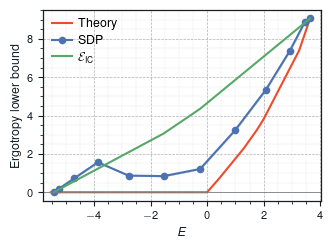

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# --- PRL column width (same logic you used before)
fig_width_pt = 246.0
inches_per_pt = 1.0 / 72.27
fig_width = fig_width_pt * inches_per_pt
fig_height = 0.75 * fig_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# --- padding
x_min, x_max = E_grid.min(), E_grid.max()
padding = 0.03 * (x_max - x_min)
ax.set_xlim([x_min - padding, x_max + padding])

# --- theoretical curve
ax.plot(
    E_grid,
    theory_curve,
    color="#EE4B2B",
    linestyle='-',
    label=r'Theory'
)

# --- SDP IQR region
color_sdp = "#4C72B0"
ax.fill_between(
    E_values,
    sdp_lower_clipped,
    sdp_upper_clipped,
    color=color_sdp,
    alpha=0.25
)

# --- SDP median
ax.plot(
    E_values,
    sdp_medians_clipped,
    marker='o',
    linestyle='-',
    color=color_sdp,
    label=r'SDP'
)

# --- incoherent lower bound
ax.plot(
    E_values,
    incoh_LBs,
    color="#55A868",
    linestyle='-',
    label=r'$\mathcal{E}_{\mathrm{IC}}$'
)

# --- zero line
ax.axhline(0, color='gray', linewidth=0.6)

# --- AXIS LABELS (LaTeX)
ax.set_xlabel(r'$E$')
ax.set_ylabel(r'Ergotropy lower bound')

# --- grid (as in your original)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', linestyle=':', linewidth=0.2)

# --- legend
ax.legend(loc='best')

plt.tight_layout()

# --- save
fname = f"comparison_theory_vs_SDP_hamiltonian_paulis_L{L}_with_incohLB_plots_def.pdf"
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()


In [70]:
import os
os.environ['PATH'] += os.pathsep + '/Library/TeX/texbin'

import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "pgf.texsystem": "lualatex",
    "pgf.rcfonts": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
})

mpl.rcParams['text.latex.preamble'] = r'''
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
'''


In [71]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

paper_params = {
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.linewidth": 0.9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
    "savefig.transparent": True,
}

rcParams.update(paper_params)


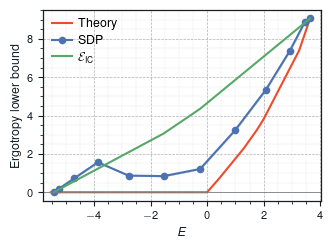

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# --- PRL column width (same logic you used before)
fig_width_pt = 246.0
inches_per_pt = 1.0 / 72.27
fig_width = fig_width_pt * inches_per_pt
fig_height = 0.75 * fig_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# --- padding
x_min, x_max = E_grid.min(), E_grid.max()
padding = 0.03 * (x_max - x_min)
ax.set_xlim([x_min - padding, x_max + padding])

# --- theoretical curve
ax.plot(
    E_grid,
    theory_curve,
    color="#EE4B2B",
    linestyle='-',
    label=r'Theory'
)

# --- SDP IQR region
color_sdp = "#4C72B0"
ax.fill_between(
    E_values,
    sdp_lower_clipped,
    sdp_upper_clipped,
    color=color_sdp,
    alpha=0.25
)

# --- SDP median
ax.plot(
    E_values,
    sdp_medians_clipped,
    marker='o',
    linestyle='-',
    color=color_sdp,
    label=r'SDP'
)

# --- incoherent lower bound
ax.plot(
    E_values,
    incoh_LBs,
    color="#55A868",
    linestyle='-',
    label=r'$\mathcal{E}_{\mathrm{IC}}$'
)

# --- zero line
ax.axhline(0, color='gray', linewidth=0.6)

# --- AXIS LABELS (LaTeX)
ax.set_xlabel(r'$E$')
ax.set_ylabel(r'Ergotropy lower bound')

# --- grid (as in your original)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', linestyle=':', linewidth=0.2)

# --- legend
ax.legend(loc='best')

plt.tight_layout()

# --- save
fname = f"comparison_theory_vs_SDP_hamiltonian_paulis_L{L}_with_incohLB_plots_def.pdf"
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()
